<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-PablUoo/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Roteiro do projeto: Wine Quality UCI

| Etapa | O que faremos |
|-------|---------------|
| **0** | Instalação e importação das bibliotecas |
| **1** | LOAD: Carregar o dataset `winequality` já existente |
| **2** | EDA: Explorar o dataset com estatísticas e plots (distribuição de qualidade, histogramas, matriz de correlação, boxplots) |
| **3** | Escrever as descobertas principais |


---
## Etapa 0 · Importando as bibliotecas

Antes de qualquer coisa, precisamos importar as ferramentas que vamos usar. Na prática de Machine Learning, quase sempre usamos o mesmo conjunto de bibliotecas:

- `numpy` e `pandas` → manipulação de dados
- `matplotlib` e `seaborn` → visualizações
- `scikit-learn` → os algoritmos de ML

In [1]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
ds = 'winequality/winequality-red.csv'
ds2 = 'winequality/winequality-white.csv'
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


---
## Etapa 1 · Conhecendo o dataset

Vamos usar o **Wine Quality Dataset** — dataset do repositório UCI Machine Learning, com dados físico-químicos de vinhos portugueses da região do Minho.

### O problema
Analisar as **propriedades químicas** dos vinhos e sua relação com a **qualidade** (nota de 0 a 10 atribuída por sommeliers).

### As features (atributos de entrada)
Cada vinho é descrito por **11 propriedades** químicas:

| Feature | Descrição |
|---------|-----------|
| `fixed acidity` | Acidez fixa |
| `volatile acidity` | Acidez volátil |
| `citric acid` | Ácido cítrico |
| `residual sugar` | Açúcar residual |
| `chlorides` | Cloretos |
| `free sulfur dioxide` | Dióxido de enxofre livre |
| `total sulfur dioxide` | Dióxido de enxofre total |
| `density` | Densidade |
| `pH` | pH |
| `sulphates` | Sulfatos |
| `alcohol` | Teor alcoólico |

### O dataset
Temos dois arquivos, um para cada tipo de vinho:
- **Tinto** (`winequality-red.csv`): 1.599 amostras
- **Branco** (`winequality-white.csv`): 4.898 amostras

In [2]:
# Carregando o dataset real do Wine Quality
red = pd.read_csv('winequality/winequality-red.csv', sep=';')
white = pd.read_csv('winequality/winequality-white.csv', sep=';')

red['tipo'] = 'tinto'
white['tipo'] = 'branco'

wine = pd.concat([red, white], ignore_index=True)

print(f"Total de amostras: {len(wine)}")
print(f"Colunas: {wine.columns.tolist()}")
print(wine.head())

Total de amostras: 6497
Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'tipo']
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3          

---
## Etapa 2 · Análise Exploratória (EDA)

Vamos explorar o dataset com estatísticas descritivas e visualizações para entender:
- A distribuição das notas de qualidade
- O comportamento de cada variável química
- As correlações entre as variáveis
- As diferenças entre vinhos tintos e brancos

---
## Etapa 3 · Descobertas Principais

---

### 🔍 Descoberta 1 — Teor alcoólico é o fator que mais influencia a qualidade

**Afirmação:** Vinhos com maior teor alcoólico tendem a receber notas mais altas dos avaliadores.

**Evidência:** A correlação de Pearson entre `alcohol` e `quality` é **+0,44** — a mais alta de todas as variáveis. Além disso, a média de álcool sobe progressivamente com a nota: vinhos nota 5 têm média de **9,84%**, enquanto os nota 9 atingem **12,18%** (veja boxplot e tabela abaixo).

**Interpretação:** O teor alcoólico é o preditor individual mais forte da qualidade nesse dataset. Uma possível explicação é que vinhos com mais álcool costumam vir de uvas mais maduras, que desenvolvem sabores mais complexos — características valorizadas pelos sommeliers.

---

### 🔍 Descoberta 2 — Acidez volátil elevada penaliza a nota

**Afirmação:** Quanto maior a acidez volátil (`volatile acidity`), menor tende a ser a nota do vinho.

**Evidência:** A correlação entre `volatile acidity` e `quality` é **−0,27**. Os vinhos tintos apresentam acidez volátil média de **0,53**, enquanto os brancos têm apenas **0,28** — e os tintos recebem nota média de **5,64** versus **5,88** dos brancos. Nos boxplots, vinhos nota 3 e 4 concentram os maiores valores de acidez volátil.

**Interpretação:** A acidez volátil é causada principalmente pelo ácido acético (vinagre), que em concentrações altas torna o vinho desagradável ao paladar. Isso explica a penalização nas notas — é uma das variáveis com maior impacto negativo na qualidade percebida.

---

### 🔍 Descoberta 3 — O dataset é fortemente desbalanceado: notas extremas são raras

**Afirmação:** A grande maioria dos vinhos recebe nota 5 ou 6, e vinhos excelentes (nota 9) são extremamente raros.

**Evidência:** Das 6.497 amostras, **75,7% têm nota 5 ou 6** (2.138 + 2.836 = 4.974 vinhos). Apenas **5 vinhos** recebem nota 9, e **30** recebem nota 3 (os piores). O histograma de qualidade exibe uma distribuição aproximadamente normal centrada em 6, com caudas muito finas nas extremidades.

**Interpretação:** Esse desbalanceamento é uma limitação importante do dataset para tarefas de classificação — modelos de ML tendem a favorecer as classes majoritárias (5 e 6) e ter dificuldade em identificar vinhos excepcionais ou ruins. Para análises preditivas, seria necessário aplicar técnicas de reamostragem (oversampling/undersampling).


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


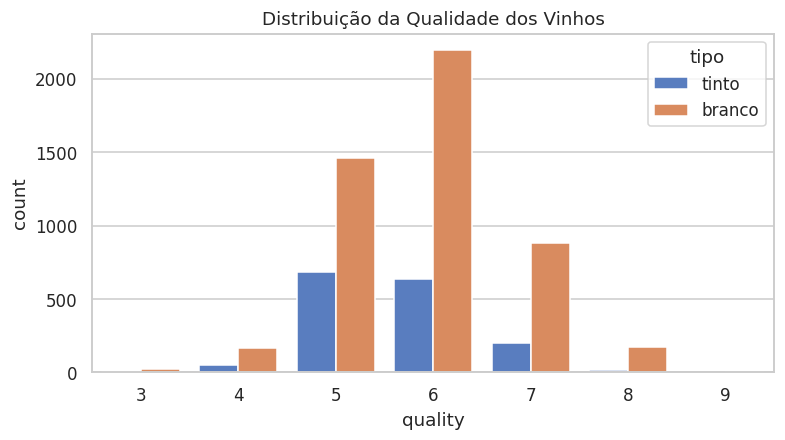

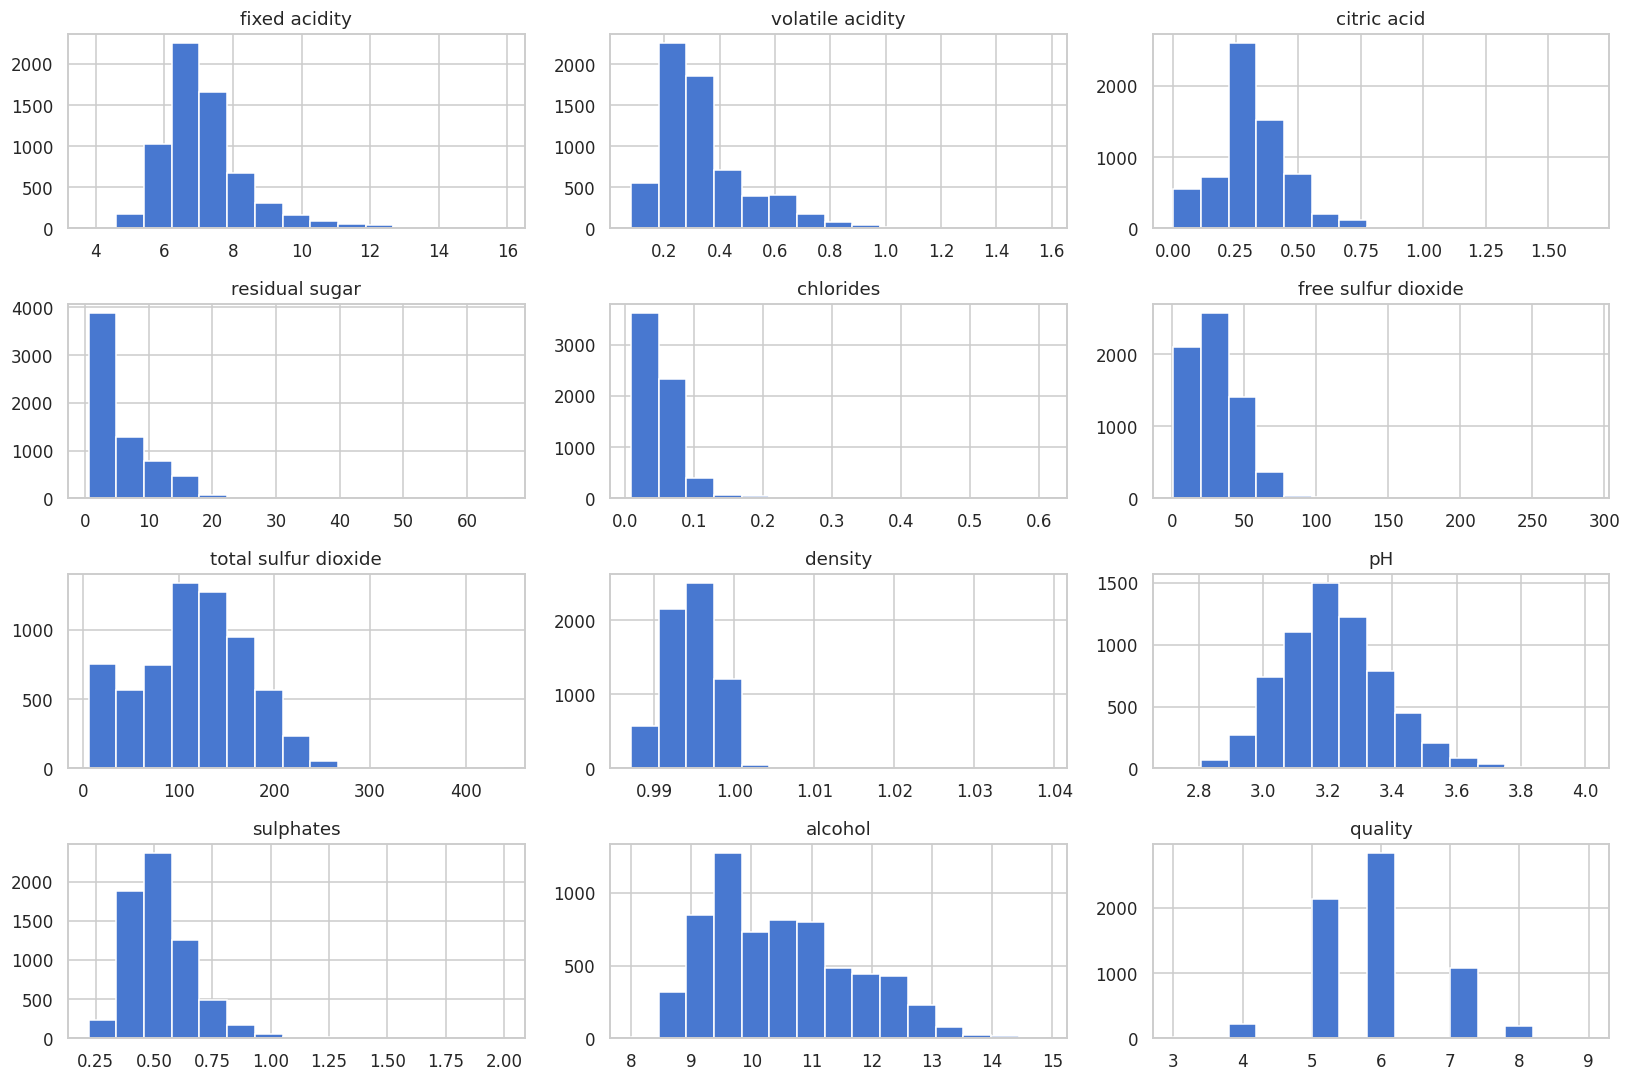

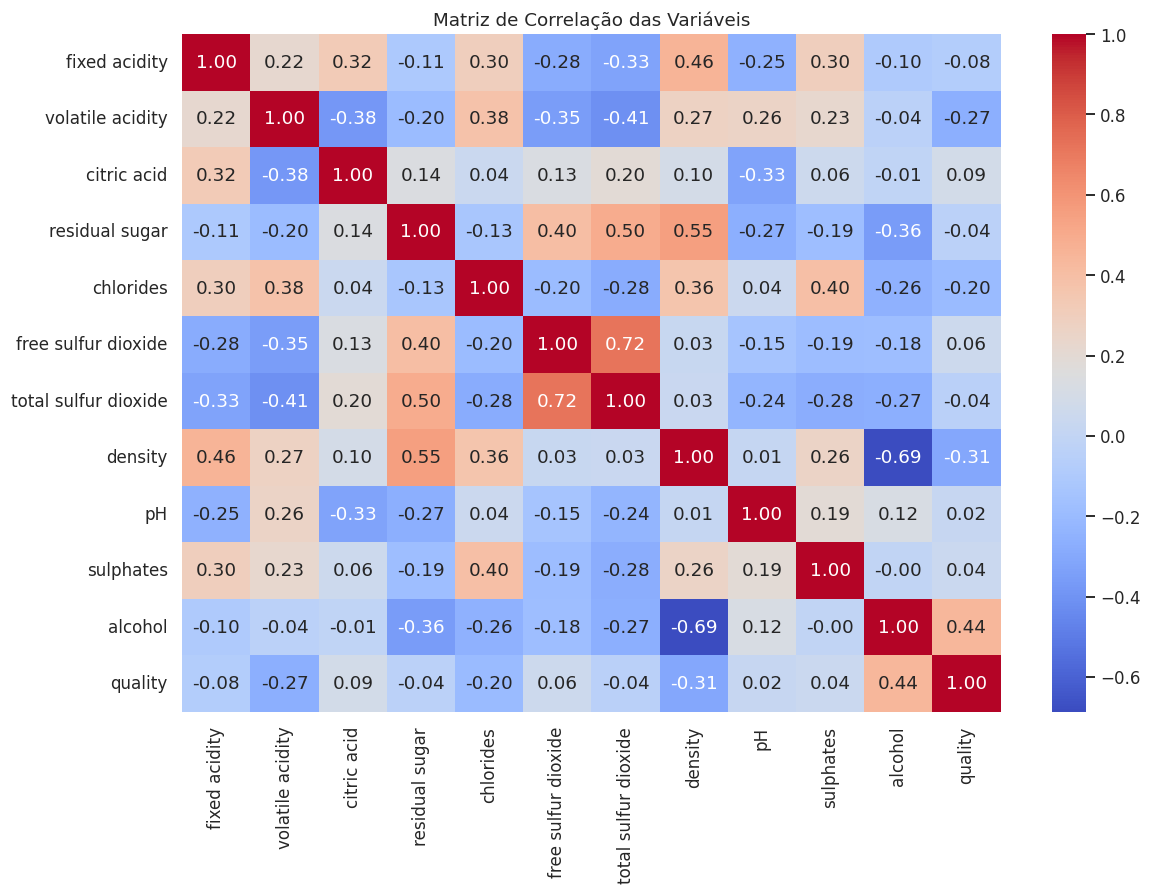

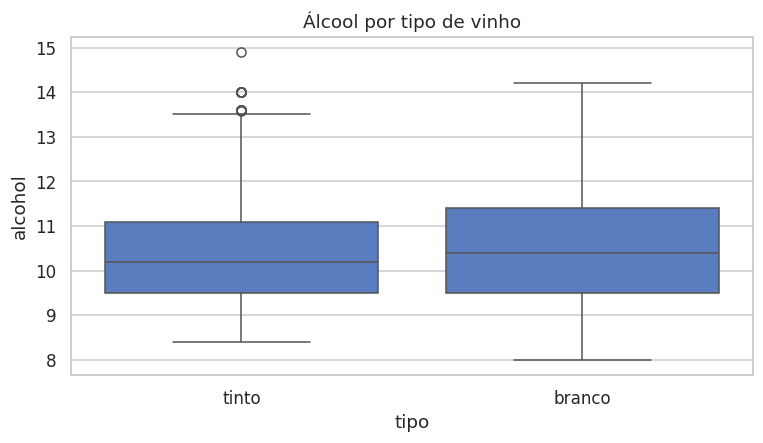

In [3]:
# Estatísticas descritivas gerais
display(wine.describe())

# Distribuição da variável alvo (qualidade)
plt.figure(figsize=(8,4))
sns.countplot(data=wine, x='quality', hue='tipo')
plt.title('Distribuição da Qualidade dos Vinhos')
plt.show()

# Histograma de algumas variáveis
wine.hist(bins=15, figsize=(15,10), layout=(4,3))
plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(12,8))
sns.heatmap(wine.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

# Boxplot de álcool por tipo
plt.figure(figsize=(8,4))
sns.boxplot(data=wine, x='tipo', y='alcohol')
plt.title('Álcool por tipo de vinho')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evidências das Descobertas Principais', fontsize=14, fontweight='bold')

# Descoberta 1 — Boxplot: álcool por nota de qualidade, Média de álcool por nota (tabela visual)
sns.boxplot(data=wine, x='quality', y='alcohol', palette='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Descoberta 1 · Álcool por Nota de Qualidade')
axes[0, 0].set_xlabel('Nota de Qualidade')
axes[0, 0].set_ylabel('Teor Alcoólico (%)')

media_alc = wine.groupby('quality')['alcohol'].mean()
axes[0, 1].bar(media_alc.index, media_alc.values, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Descoberta 1 · Média de Álcool por Nota')
axes[0, 1].set_xlabel('Nota de Qualidade')
axes[0, 1].set_ylabel('Média de Álcool (%)')
for i, (q, v) in enumerate(media_alc.items()):
    axes[0, 1].text(q, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# Descoberta 2 — Boxplot: acidez volátil por nota de qualidade
sns.boxplot(data=wine, x='quality', y='volatile acidity', palette='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Descoberta 2 · Acidez Volátil por Nota de Qualidade')
axes[1, 0].set_xlabel('Nota de Qualidade')
axes[1, 0].set_ylabel('Acidez Volátil')

# Descoberta 3 — Distribuição de qualidade (balanceamento)
counts = wine['quality'].value_counts().sort_index()
bars = axes[1, 1].bar(counts.index, counts.values,
                      color=['#d62728' if v < 500 else '#1f77b4' for v in counts.values],
                      edgecolor='white')
axes[1, 1].set_title('Descoberta 3 · Distribuição das Notas (Desbalanceamento)')
axes[1, 1].set_xlabel('Nota de Qualidade')
axes[1, 1].set_ylabel('Número de Vinhos')
for bar, (q, v) in zip(bars, counts.items()):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tabela de correlações com qualidade
print("\n📊 Correlações de Pearson com 'quality' (ordenadas):")
corr_quality = wine.select_dtypes(include='number').corr()['quality'].drop('quality').sort_values(ascending=False)
print(corr_quality.to_string())
